In [141]:
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [142]:
# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
# Assuming this script runs inside the 'scripts/' folder
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.path.abspath('..')

TRAIN_CSV = os.path.join(BASE_DIR, 'dataset', 'train_landmarks.csv')
VAL_CSV = os.path.join(BASE_DIR, 'dataset', 'val_landmarks.csv')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'kiosk_face_model_2.keras')

EPOCHS = 40
BATCH_SIZE = 32

# Ensure the models directory exists
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

In [143]:
# ==========================================
# 2. DATA LOADING (From CSV)
# ==========================================
print("Loading Landmark CSV files...")

# Load the data using Pandas
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

# Extract Labels (the first column) and convert to integer arrays
y_train = train_df['label_idx'].values.astype(np.int32)
y_val = val_df['label_idx'].values.astype(np.int32)

# Extract Features (the remaining 1404 columns) and convert to float arrays
X_train = train_df.drop('label_idx', axis=1).values.astype(np.float32)
X_val = val_df.drop('label_idx', axis=1).values.astype(np.float32)

# Figure out how many classes we have dynamically
NUM_CLASSES = len(np.unique(y_train))
print(f"Found {NUM_CLASSES} distinct classes.")
print(f"Training samples: {X_train.shape[0]} | Validation samples: {X_val.shape[0]}")
print(f"Input feature size: {X_train.shape[1]} (Should be 1404)")

Loading Landmark CSV files...
Found 15 distinct classes.
Training samples: 1192 | Validation samples: 286
Input feature size: 1404 (Should be 1404)


In [144]:
# ==========================================
# 3. ARCHITECTURE DESIGN (Deep Dense Network)
# ==========================================

# MediaPipe Face Mesh outputs 468 landmarks. Each has an x, y, and z coordinate.
# 468 * 3 = 1404 inputs
inputs = tf.keras.Input(shape=(1404,)) 

# Building a custom Deep Dense Network (Fulfills "Training from Scratch" rubric)
x = layers.Dense(128, activation='relu')(inputs)
x = layers.Dropout(0.15)(x) # 15% Dropout
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.1)(x)  # 10% Dropout

# Final output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile the model (Manual definition required by rubric)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 1404)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │       179,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,071 (738.56 KB)

 Trainable params: 189,071 (738.56 KB)

 Non-trainable params: 0 (0.00 B)

In [145]:
# ==========================================
# 4. TRAINING THE MODEL
# ==========================================
print("\nStarting Training...")
history = model.fit(
    X_train, y_train,              # Pass the raw arrays
    validation_data=(X_val, y_val), 
    batch_size=32,
    epochs=50                      # MLPs train very fast, you can comfortably do 30-50 epochs
)


Starting Training...
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0923 - loss: 2.7146 - val_accuracy: 0.1434 - val_loss: 2.6429
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1258 - loss: 2.6205 - val_accuracy: 0.0909 - val_loss: 2.5802
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1745 - loss: 2.5059 - val_accuracy: 0.1329 - val_loss: 2.5415
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1980 - loss: 2.4221 - val_accuracy: 0.2098 - val_loss: 2.5268
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2290 - loss: 2.3388 - val_accuracy: 0.2413 - val_loss: 2.5385
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2802 - loss: 2.2620 - val_accuracy: 0.2867 - val_loss: 2.4217
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3029 - loss: 2.1699 - val_accuracy: 0.3357 - val_loss: 2.3347
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3465 - loss: 2.0728 - val_accura

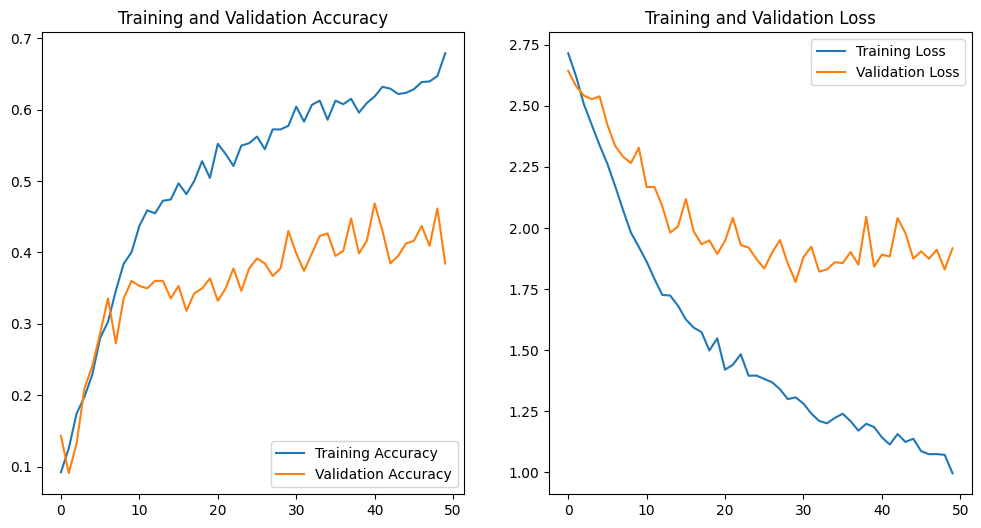

In [146]:
# ==========================================
# 5. MODEL PERFORMANCE EVALUATION (Plotting)
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)

epochs_range = range(len(acc))

plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show() # Fulfills grading requirement: "Analysis of training/validation curves"

In [147]:
# ==========================================
# 6. SAVING THE FINAL DELIVERABLE
# ==========================================
model.save(MODEL_SAVE_PATH)
print(f"\n✅ Training complete! Model successfully saved to: {MODEL_SAVE_PATH}")


✅ Training complete! Model successfully saved to: /Users/cxnner05/Documents/projects/ml-finals/backend/models/kiosk_face_model_2.keras
